# Prévision de pluie en Australie — 1/3 · Exploration

Dataset Kaggle *Rain in Australia* : dix ans de relevés quotidiens sur 49 stations. On cherche
à prédire `RainTomorrow`, c'est-à-dire s'il tombera au moins 1 mm le lendemain.

Cette partie sert à comprendre les données avant de modéliser : ce qui manque, à quel point la
cible est déséquilibrée, quelles variables portent de l'information, et quel score un modèle
doit dépasser pour être utile.

Suite : `02_preprocessing.ipynb` puis `03_modelisation.ipynb`.

## 0. Setup & chargement des données

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

In [2]:
# Résolution robuste du chemin des données : fonctionne que le notebook soit
# lancé depuis la racine du projet ou depuis le dossier notebooks/.
CANDIDATES = [
    Path("Data/weatherAUS.csv"),
    Path("../Data/weatherAUS.csv"),
    Path.home() / "Desktop/MlOps_Meteo-Liora/Data/weatherAUS.csv",
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, "weatherAUS.csv introuvable (vérifier le dossier Data/)"

df = pd.read_csv(DATA_PATH, na_values=["NA"])
print(f"Chargé depuis : {DATA_PATH}")
print(f"Dimensions    : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Chargé depuis : /home/tinkerbell/Desktop/MlOps_Meteo-Liora/Data/weatherAUS.csv
Dimensions    : 145,460 lignes × 23 colonnes


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 1. Structure et qualité

Types, doublons, puis valeurs manquantes.

In [3]:
# Types, mémoire et doublons
df.info()
print("\nDoublons exacts :", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

### 1.1 Valeurs manquantes

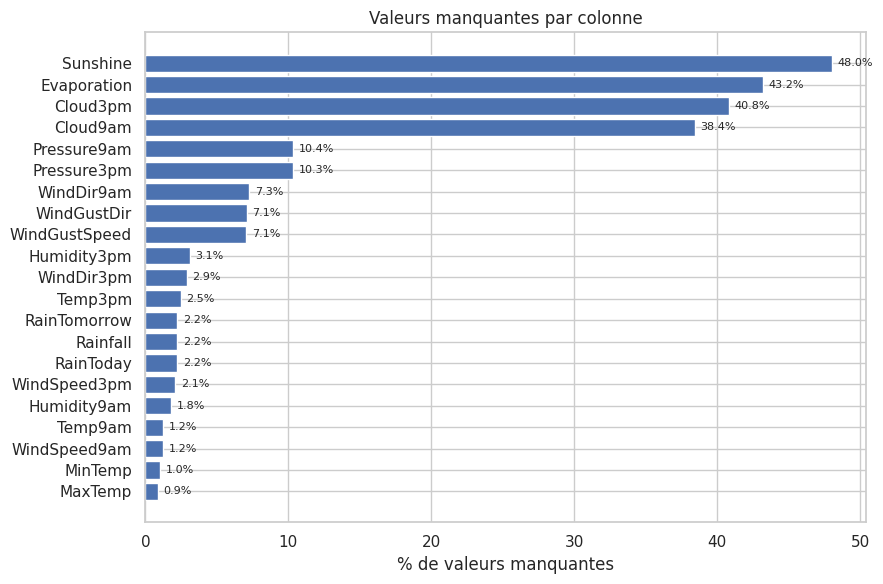

Sunshine         48.01
Evaporation      43.17
Cloud3pm         40.81
Cloud9am         38.42
Pressure9am      10.36
Pressure3pm      10.33
WindDir9am        7.26
WindGustDir       7.10
WindGustSpeed     7.06
Humidity3pm       3.10
WindDir3pm        2.91
Temp3pm           2.48
RainTomorrow      2.25
Rainfall          2.24
RainToday         2.24
WindSpeed3pm      2.11
Humidity9am       1.82
Temp9am           1.21
WindSpeed9am      1.21
MinTemp           1.02
MaxTemp           0.87
dtype: float64

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color="#4C72B0")
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par colonne")
for i, v in enumerate(missing_pct.values[::-1]):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()
missing_pct.round(2)

Quatre colonnes sont très lacunaires : `Sunshine` (48 %), `Evaporation` (43 %), `Cloud3pm`
(41 %) et `Cloud9am` (38 %). Les autres restent sous 10 %.

La tentation serait de les supprimer. On va s'en garder : la section 1.4 montre que `Sunshine`
et `Cloud3pm` sont justement les variables les mieux corrélées à la cible. Elles seront
conservées et imputées, en gardant en tête que près d'une valeur sur deux sera reconstituée.

`RainTomorrow` manque sur 2,2 % des lignes. Ces lignes ne servent à rien pour un apprentissage
supervisé, elles seront retirées.

### 1.2 Variable cible & déséquilibre

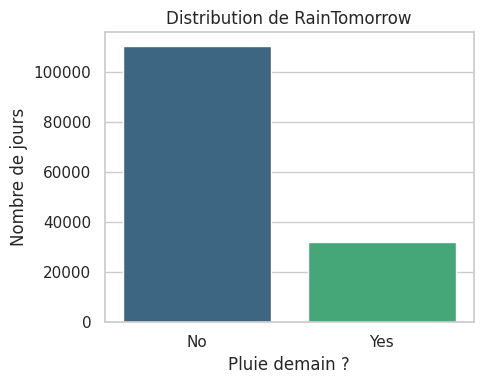

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

Taux de base (Yes) = 22.42%  ->  classe fortement déséquilibrée (~78/22).


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
order = ["No", "Yes"]
sns.countplot(x="RainTomorrow", data=df, order=order,
              hue="RainTomorrow", hue_order=order, palette="viridis", legend=False, ax=ax)
ax.set_title("Distribution de RainTomorrow")
ax.set_xlabel("Pluie demain ?")
ax.set_ylabel("Nombre de jours")
plt.tight_layout()
plt.show()

vc = df["RainTomorrow"].value_counts(dropna=False)
base_rate = 100 * vc.get("Yes", 0) / (vc.get("Yes", 0) + vc.get("No", 0))
print(vc)
print(f"\nTaux de base (Yes) = {base_rate:.2f}%  ->  classe fortement déséquilibrée (~78/22).")

Il pleut le lendemain dans 22 % des cas. Ce déséquilibre pèse sur tout le reste : un modèle
qui répondrait systématiquement « non » afficherait déjà 78 % d'accuracy sans rien avoir appris.

On suivra donc le rappel et le F1 de la classe « pluie », pas l'accuracy globale.

### 1.3 Deux points de comparaison

Avant de lancer un modèle, autant savoir ce qu'il doit battre. La première baseline répond
toujours « non ». La seconde, dite de persistance, recopie la météo du jour : c'est ce que ferait
quelqu'un sans aucune donnée, et en météo c'est étonnamment difficile à battre.

In [6]:
valid = df.dropna(subset=["RainTomorrow"]).copy()

# Baseline 1 : prédire toujours "No"
acc_always_no = 100 * (valid["RainTomorrow"] == "No").mean()

# Baseline 2 : persistance -> "demain = aujourd'hui" (RainTomorrow == RainToday)
persist = valid.dropna(subset=["RainToday"])
acc_persist = 100 * (persist["RainTomorrow"] == persist["RainToday"]).mean()
p_yes_if_today_yes = 100 * (persist.loc[persist.RainToday == "Yes", "RainTomorrow"] == "Yes").mean()
p_yes_if_today_no = 100 * (persist.loc[persist.RainToday == "No", "RainTomorrow"] == "Yes").mean()

print(f"Baseline 'toujours Non'        : accuracy = {acc_always_no:.2f}%")
print(f"Baseline persistance (=RainToday): accuracy = {acc_persist:.2f}%")
print(f"  P(pluie demain | il a plu aujourd'hui)   = {p_yes_if_today_yes:.1f}%")
print(f"  P(pluie demain | pas de pluie aujourd'hui) = {p_yes_if_today_no:.1f}%")

Baseline 'toujours Non'        : accuracy = 77.58%
Baseline persistance (=RainToday): accuracy = 76.23%
  P(pluie demain | il a plu aujourd'hui)   = 46.4%
  P(pluie demain | pas de pluie aujourd'hui) = 15.2%


La barre est à 78 % pour « toujours non » et 76 % pour la persistance. Autrement dit, un modèle
à 80 % d'accuracy n'apporterait presque rien.

Le détail est plus intéressant que le score : quand il a plu aujourd'hui, la probabilité de pluie
demain passe à 46 %, contre 15 % sinon. `RainToday` porte donc une vraie information — c'est
aussi une variable à surveiller, puisqu'elle dérive de `Rainfall` et pourrait créer une fuite si
on l'utilisait mal.

### 1.4 Variables explicatives — corrélations avec la cible

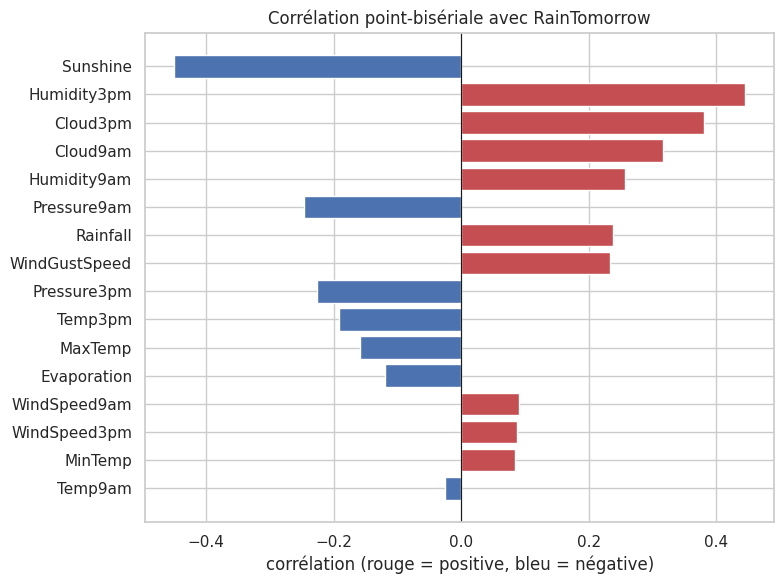

Sunshine        -0.451
Humidity3pm      0.446
Cloud3pm         0.382
Cloud9am         0.317
Humidity9am      0.257
Pressure9am     -0.246
Rainfall         0.239
WindGustSpeed    0.234
Pressure3pm     -0.226
Temp3pm         -0.192
MaxTemp         -0.159
Evaporation     -0.119
WindSpeed9am     0.091
WindSpeed3pm     0.088
MinTemp          0.084
Temp9am         -0.026
dtype: float64

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
y_bin = df["RainTomorrow"].map({"Yes": 1, "No": 0})

corr = {}
for c in num_cols:
    sub = pd.DataFrame({"x": df[c], "y": y_bin}).dropna()
    corr[c] = sub["x"].corr(sub["y"])
corr = pd.Series(corr).sort_values(key=np.abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Corrélation point-bisériale avec RainTomorrow")
ax.set_xlabel("corrélation (rouge = positive, bleu = négative)")
plt.tight_layout()
plt.show()
corr.sort_values(key=np.abs, ascending=False).round(3)

Quatre variables se détachent : l'ensoleillement (−0,45), l'humidité de l'après-midi (+0,45),
la nébulosité de l'après-midi (+0,38) et la pression (−0,23).

Rien de surprenant physiquement : moins de soleil, plus d'humidité et de nuages, une pression qui
baisse, et la pluie devient probable. Les mesures de 15 h sont plus prédictives que celles de 9 h,
ce qui est cohérent avec un horizon de prévision de 24 h.

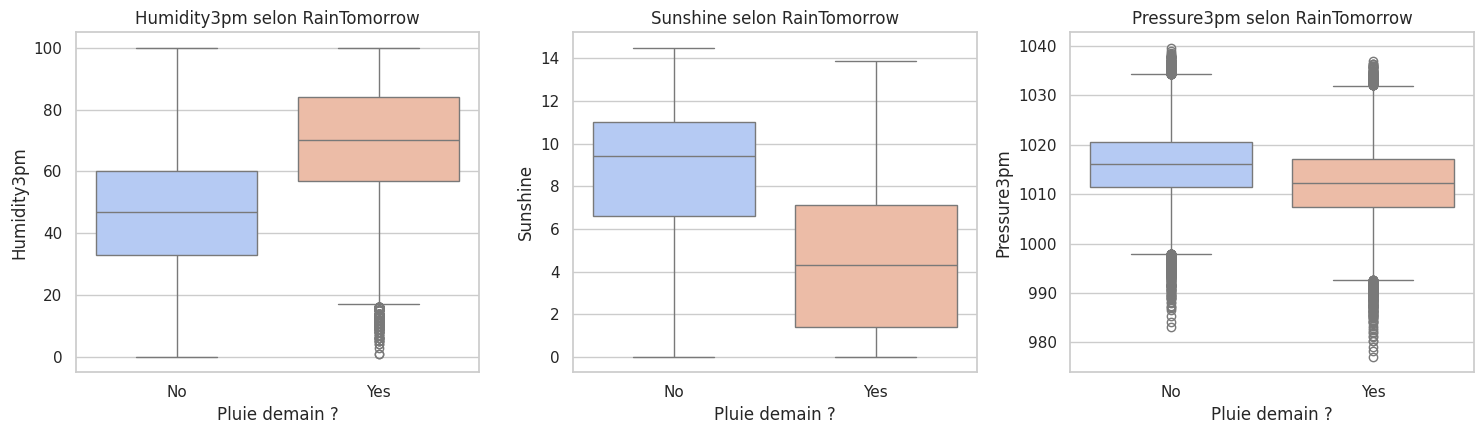

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["Humidity3pm", "Sunshine", "Pressure3pm"]):
    sns.boxplot(x="RainTomorrow", y=col, data=df, order=["No", "Yes"],
                hue="RainTomorrow", hue_order=["No", "Yes"],
                palette="coolwarm", legend=False, ax=ax)
    ax.set_title(f"{col} selon RainTomorrow")
    ax.set_xlabel("Pluie demain ?")
plt.tight_layout()
plt.show()

### 1.5 Géographie et saison

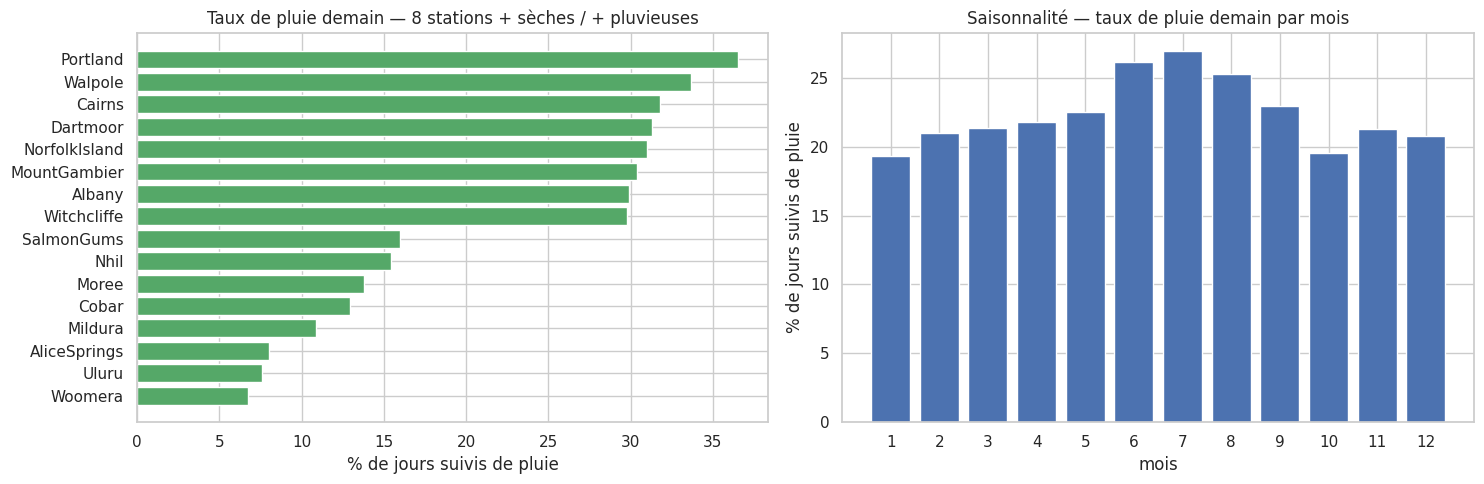

Mois le + pluvieux: 7 (26.9%) | + sec: 1 (19.3%)


In [9]:
rate_loc = (valid.assign(y=lambda d: (d.RainTomorrow == "Yes"))
            .groupby("Location")["y"].mean().mul(100).sort_values())
top = pd.concat([rate_loc.head(8), rate_loc.tail(8)])

df["_month"] = pd.to_datetime(df["Date"], errors="coerce").dt.month
rate_month = (df.dropna(subset=["RainTomorrow", "_month"])
              .assign(y=lambda d: (d.RainTomorrow == "Yes"))
              .groupby("_month")["y"].mean().mul(100))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(top.index, top.values, color="#55A868")
axes[0].set_title("Taux de pluie demain — 8 stations + sèches / + pluvieuses")
axes[0].set_xlabel("% de jours suivis de pluie")
axes[1].bar(rate_month.index, rate_month.values, color="#4C72B0")
axes[1].set_title("Saisonnalité — taux de pluie demain par mois")
axes[1].set_xlabel("mois")
axes[1].set_ylabel("% de jours suivis de pluie")
axes[1].set_xticks(range(1, 13))
plt.tight_layout()
plt.show()
print("Mois le + pluvieux:", int(rate_month.idxmax()), f"({rate_month.max():.1f}%)",
      "| + sec:", int(rate_month.idxmin()), f"({rate_month.min():.1f}%)")

L'écart entre stations est considérable : de 7 % de jours suivis de pluie à Woomera et Uluru,
en plein désert, à 37 % à Portland sur la côte sud. Un modèle global devra donc apprendre des
régimes très différents, ce qui plaide pour garder `Location` comme variable.

La saisonnalité est plus discrète mais nette : pic en hiver austral (juin à août, 26-27 %) et
creux en janvier (19 %). De quoi justifier d'extraire le mois de la date, ce que fera le
notebook suivant.